## Exercise 1 Hotdog -- no hotdog

In [6]:
import os
import numpy as np
import glob
import PIL.Image as Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [7]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f"Using device: {device}")

Using device: mps


In [8]:
class Hotdog_NotHotdog(torch.utils.data.Dataset):
    def __init__(self, train, transform, data_path='hotdog_nothotdog'):
        'Initialization'
        self.transform = transform
        data_path = os.path.join(data_path, 'train' if train else 'test')
        image_classes = [os.path.split(d)[1] for d in glob.glob(data_path +'/*') if os.path.isdir(d)]
        image_classes.sort()
        self.name_to_label = {c: id for id, c in enumerate(image_classes)}
        self.image_paths = glob.glob(data_path + '/*/*.jpg')
        
    def __len__(self):
        'Returns the total number of samples'
        return len(self.image_paths)

    def __getitem__(self, idx):
        'Generates one sample of data'
        image_path = self.image_paths[idx]
        
        image = Image.open(image_path)
        c = os.path.split(os.path.split(image_path)[0])[1]
        y = self.name_to_label[c]
        X = self.transform(image)
        return X, y

In [9]:
size = 128
train_transform = transforms.Compose([transforms.Resize((size, size)), 
                                    transforms.ToTensor()])
test_transform = transforms.Compose([transforms.Resize((size, size)), 
                                    transforms.ToTensor()])

batch_size = 64
trainset = Hotdog_NotHotdog(train=True, transform=train_transform)

# 80/20 train/val split for model selection without test leakage
train_size = int(0.8 * len(trainset))
val_size = len(trainset) - train_size
train_subset, val_subset = torch.utils.data.random_split(
    trainset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=0)
testset = Hotdog_NotHotdog(train=False, transform=test_transform)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Train samples: {len(train_subset)}, Val samples: {len(val_subset)}, Test samples: {len(testset)}")


Train samples: 1637, Val samples: 410, Test samples: 1862


Images batch shape: torch.Size([64, 3, 128, 128])
Labels batch shape: torch.Size([64])
Pixel range: min = 0.0 max = 1.0


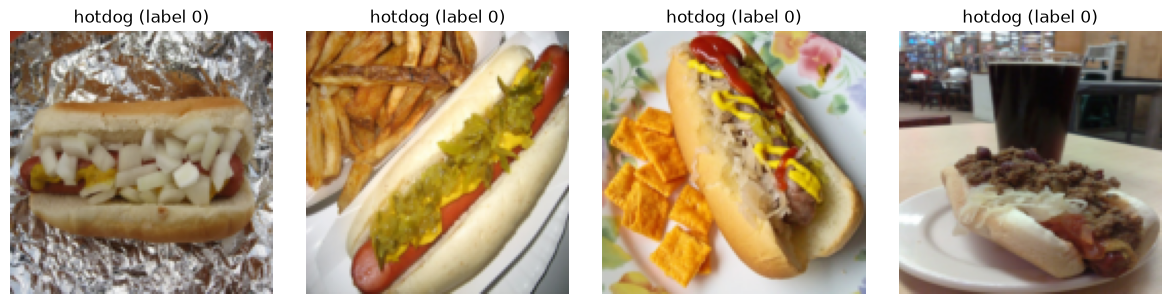

In [10]:
# Visual sanity check: Verify labels and pixel values
classes = ["hotdog", "not hotdog"]
images, labels = next(iter(train_loader))
print("Images batch shape:", images.shape)
print("Labels batch shape:", labels.shape)
print("Pixel range: min =", images.min().item(), "max =", images.max().item())

plt.figure(figsize=(12, 3))
for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.imshow(images[i].permute(1, 2, 0))
    plt.title(f"{classes[labels[i]]} (label {labels[i].item()})")
    plt.axis("off")
plt.tight_layout()
plt.show()


## Step 2: Baseline Architecture (From First Principles)

**Design Strategy:**
1. Start with a simple, standard 3-stage CNN to establish a performance floor.
2. Pattern: .
3. Output: 2 logits (index 0: hotdog, index 1: not hotdog).
4. We deliberately omit BatchNorm and Dropout here so we can measure their exact contribution later.

In [11]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Feature Extractor
        # Stage 1: (3, 128, 128) -> (16, 64, 64)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Stage 2: (16, 64, 64) -> (32, 32, 32)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Stage 3: (32, 32, 32) -> (64, 16, 16)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Classifier Head: 64 * 16 * 16 = 16384
        self.fc1 = nn.Linear(64 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, 2)
        
    def forward(self, x):
        # Feature extraction
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))
        
        # Flatten: (batch_size, 64 * 16 * 16)
        x = torch.flatten(x, start_dim=1)
        
        # Classification
        x = F.relu(self.fc1(x))
        logits = self.fc2(x)
        return logits

# Instantiate and test forward pass
model = BaselineCNN().to(device)
print(model)

# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Trainable Parameters: {total_params:,}")

# Test forward pass with a dummy batch on device
dummy_x = torch.randn(4, 3, 128, 128, device=device)
dummy_out = model(dummy_x)
print(f"Test forward pass output shape: {dummy_out.shape}  (batch_size=4, num_classes=2)")


BaselineCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)
Total Trainable Parameters: 2,121,122
Test forward pass output shape: torch.Size([4, 2])  (batch_size=4, num_classes=2)


## Step 3: Training the Baseline Model

**First Principles of Training:**
1. **Loss Function (CrossEntropyLoss):** Measures the distance between predicted class logits and true class labels via negative log-likelihood.
2. **Optimizer (Adam, lr=0.001):** Uses adaptive learning rates for each parameter, providing a robust, fast-converging baseline.
3. **Train vs. Eval Separation:** Training computes gradients and updates weights (model.train()); validation computes metrics without gradients (torch.no_grad()).

--- Starting Baseline Training (Adam, lr=0.001) ---
Epoch [01/10] | Train Loss: 0.6980, Acc: 55.16% | Val Loss: 0.6622, Acc: 57.32%
Epoch [02/10] | Train Loss: 0.5940, Acc: 69.88% | Val Loss: 0.5867, Acc: 68.78%
Epoch [03/10] | Train Loss: 0.5413, Acc: 73.24% | Val Loss: 0.5572, Acc: 70.24%
Epoch [04/10] | Train Loss: 0.5224, Acc: 74.77% | Val Loss: 0.5508, Acc: 70.73%
Epoch [05/10] | Train Loss: 0.5001, Acc: 76.05% | Val Loss: 0.5400, Acc: 71.22%
Epoch [06/10] | Train Loss: 0.4894, Acc: 77.46% | Val Loss: 0.5567, Acc: 71.46%
Epoch [07/10] | Train Loss: 0.4740, Acc: 77.83% | Val Loss: 0.5416, Acc: 70.98%
Epoch [08/10] | Train Loss: 0.4782, Acc: 77.89% | Val Loss: 0.5642, Acc: 70.49%
Epoch [09/10] | Train Loss: 0.4486, Acc: 79.66% | Val Loss: 0.5279, Acc: 72.68%
Epoch [10/10] | Train Loss: 0.4164, Acc: 81.61% | Val Loss: 0.5603, Acc: 72.93%
--- Training Finished in 143.6s ---


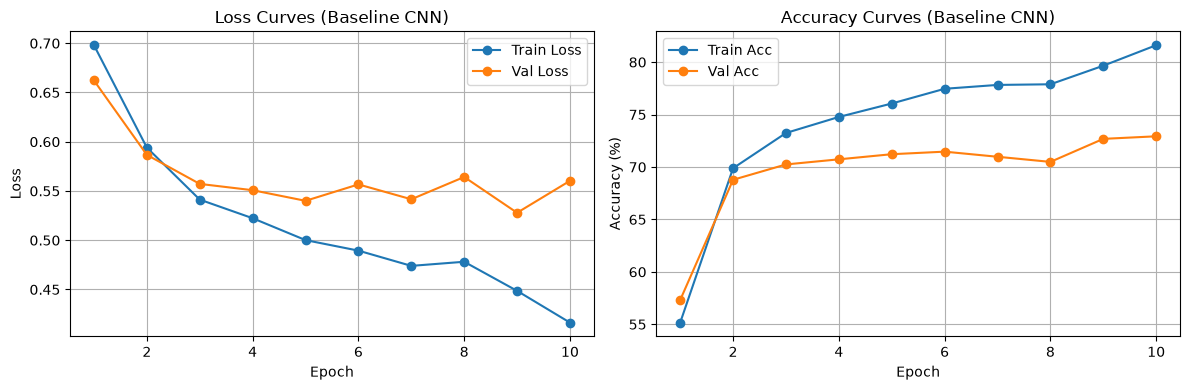

In [12]:
import time

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        # 1. Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # 2. Backward pass & optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Track metrics
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
        
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
            
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

# Setup training components
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epochs = 10

history = {
    "train_loss": [], "train_acc": [],
    "val_loss": [], "val_acc": []
}

print("--- Starting Baseline Training (Adam, lr=0.001) ---")
start_time = time.time()

for epoch in range(num_epochs):
    t_loss, t_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    v_loss, v_acc = evaluate(model, val_loader, criterion, device)
    
    history["train_loss"].append(t_loss)
    history["train_acc"].append(t_acc)
    history["val_loss"].append(v_loss)
    history["val_acc"].append(v_acc)
    
    print(f"Epoch [{epoch+1:02d}/{num_epochs:02d}] | " 
          f"Train Loss: {t_loss:.4f}, Acc: {t_acc*100:.2f}% | " 
          f"Val Loss: {v_loss:.4f}, Acc: {v_acc*100:.2f}%")

total_time = time.time() - start_time
print(f"--- Training Finished in {total_time:.1f}s ---")

# Plot training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), history["train_loss"], label="Train Loss", marker="o")
plt.plot(range(1, num_epochs + 1), history["val_loss"], label="Val Loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves (Baseline CNN)")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), [a * 100 for a in history["train_acc"]], label="Train Acc", marker="o")
plt.plot(range(1, num_epochs + 1), [a * 100 for a in history["val_acc"]], label="Val Acc", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curves (Baseline CNN)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Step 3.1: Evaluate Baseline on Unseen Test Set
We evaluate our trained Baseline CNN on the 1,862 test images to lock in our initial benchmark score.

In [13]:
# Evaluate Baseline CNN on the test set
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"=== Baseline CNN Test Performance ===")
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc * 100:.2f}%")

=== Baseline CNN Test Performance ===
Test Loss:     0.5739
Test Accuracy: 71.97%


## Step 4: Comparing Optimizers (Adam vs. SGD + Momentum)

**Exam Question:** *"Which optimizer did you use? Did you compare using different optimizers?"*

**First Principles:**
1. **Adam (Adaptive Moments):** Scales step size for each parameter individually using moving averages of gradients and squared gradients. Converges rapidly and reliably.
2. **SGD with Momentum (momentum=0.9, lr=0.01):** Simulates a heavy ball rolling down the loss landscape, accumulating velocity in consistent directions and dampening oscillations across narrow ravines. Often discovers flatter, better-generalizing minima in computer vision.

--- Starting Training with SGD + Momentum (lr=0.01, momentum=0.9) ---
Epoch [01/10] | Train Loss: 0.6916, Acc: 52.05% | Val Loss: 0.6968, Acc: 49.27%
Epoch [02/10] | Train Loss: 0.6869, Acc: 53.33% | Val Loss: 0.6875, Acc: 67.56%
Epoch [03/10] | Train Loss: 0.6790, Acc: 60.29% | Val Loss: 0.6693, Acc: 70.98%
Epoch [04/10] | Train Loss: 0.6370, Acc: 69.52% | Val Loss: 0.6082, Acc: 71.95%
Epoch [05/10] | Train Loss: 0.5821, Acc: 71.78% | Val Loss: 0.6546, Acc: 65.37%
Epoch [06/10] | Train Loss: 0.5700, Acc: 72.82% | Val Loss: 0.5683, Acc: 71.71%
Epoch [07/10] | Train Loss: 0.5320, Acc: 75.87% | Val Loss: 0.5439, Acc: 74.15%
Epoch [08/10] | Train Loss: 0.5092, Acc: 77.70% | Val Loss: 0.5440, Acc: 73.41%
Epoch [09/10] | Train Loss: 0.4998, Acc: 77.70% | Val Loss: 0.5285, Acc: 73.90%
Epoch [10/10] | Train Loss: 0.4760, Acc: 78.92% | Val Loss: 0.5365, Acc: 73.90%
--- SGD Training Finished in 150.4s ---

=== Test Performance Comparison ===
Adam: Test Loss = 0.5739, Test Acc = 71.97%
SGD:  Tes

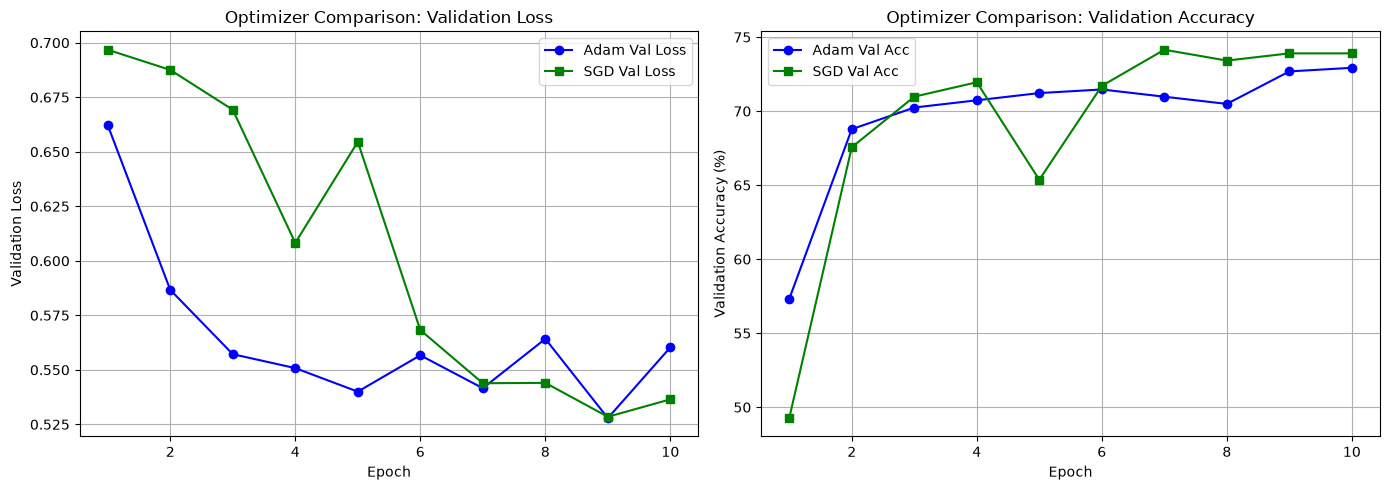

In [14]:
# Instantiate a fresh, identical Baseline CNN to ensure a fair comparison
model_sgd = BaselineCNN().to(device)

optimizer_sgd = torch.optim.SGD(model_sgd.parameters(), lr=0.01, momentum=0.9)
criterion = nn.CrossEntropyLoss()
num_epochs = 10

history_sgd = {
    "train_loss": [], "train_acc": [],
    "val_loss": [], "val_acc": []
}

print("--- Starting Training with SGD + Momentum (lr=0.01, momentum=0.9) ---")
start_time = time.time()

for epoch in range(num_epochs):
    t_loss, t_acc = train_epoch(model_sgd, train_loader, criterion, optimizer_sgd, device)
    v_loss, v_acc = evaluate(model_sgd, val_loader, criterion, device)
    
    history_sgd["train_loss"].append(t_loss)
    history_sgd["train_acc"].append(t_acc)
    history_sgd["val_loss"].append(v_loss)
    history_sgd["val_acc"].append(v_acc)
    
    print(f"Epoch [{epoch+1:02d}/{num_epochs:02d}] | " 
          f"Train Loss: {t_loss:.4f}, Acc: {t_acc*100:.2f}% | " 
          f"Val Loss: {v_loss:.4f}, Acc: {v_acc*100:.2f}%")

print(f"--- SGD Training Finished in {time.time() - start_time:.1f}s ---\n")

# Evaluate on Test Set
test_loss_sgd, test_acc_sgd = evaluate(model_sgd, test_loader, criterion, device)
print("=== Test Performance Comparison ===")
print(f"Adam: Test Loss = {test_loss:.4f}, Test Acc = {test_acc*100:.2f}%")
print(f"SGD:  Test Loss = {test_loss_sgd:.4f}, Test Acc = {test_acc_sgd*100:.2f}%\n")

# Side-by-side comparison plots
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), history["val_loss"], label="Adam Val Loss", color="blue", marker="o")
plt.plot(range(1, num_epochs + 1), history_sgd["val_loss"], label="SGD Val Loss", color="green", marker="s")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Optimizer Comparison: Validation Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), [a * 100 for a in history["val_acc"]], label="Adam Val Acc", color="blue", marker="o")
plt.plot(range(1, num_epochs + 1), [a * 100 for a in history_sgd["val_acc"]], label="SGD Val Acc", color="green", marker="s")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Optimizer Comparison: Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Step 5: Batch Normalization

**Exam Question:** *"Did you use batch normalization? Does it improve the performance?"*

**First Principles:**
1. **Internal Covariate Shift:** As early layers update their weights, the distribution of intermediate activations drifts, forcing deeper layers to continually adapt to moving targets.
2. **Mechanism (BatchNorm2d):** For each feature map across the mini-batch, BatchNorm normalizes activations to zero mean and unit variance, then applies learnable scale (gamma) and shift (beta) parameters.
3. **Benefits:** Stabilizes gradient flow, acts as a mild regularizer (reducing overfitting), and smooths the loss landscape.

--- Starting Training: CNN with Batch Normalization (Adam, lr=0.001) ---
Epoch [01/10] | Train Loss: 1.3645, Acc: 59.74% | Val Loss: 0.6810, Acc: 53.41%
Epoch [02/10] | Train Loss: 0.5136, Acc: 76.42% | Val Loss: 0.5256, Acc: 76.10%
Epoch [03/10] | Train Loss: 0.4495, Acc: 80.57% | Val Loss: 0.5432, Acc: 72.20%
Epoch [04/10] | Train Loss: 0.4127, Acc: 82.04% | Val Loss: 0.5325, Acc: 76.10%
Epoch [05/10] | Train Loss: 0.3737, Acc: 84.36% | Val Loss: 0.4905, Acc: 77.56%
Epoch [06/10] | Train Loss: 0.3458, Acc: 85.16% | Val Loss: 0.5960, Acc: 76.59%
Epoch [07/10] | Train Loss: 0.3084, Acc: 87.05% | Val Loss: 0.5337, Acc: 75.85%
Epoch [08/10] | Train Loss: 0.2796, Acc: 87.48% | Val Loss: 0.5222, Acc: 78.29%
Epoch [09/10] | Train Loss: 0.2356, Acc: 90.78% | Val Loss: 0.6294, Acc: 75.85%
Epoch [10/10] | Train Loss: 0.2025, Acc: 91.94% | Val Loss: 0.6799, Acc: 79.27%
--- Training Finished in 146.3s ---

=== Test Performance Comparison ===
Baseline CNN (No BN): Test Loss = 0.5739, Test Acc = 7

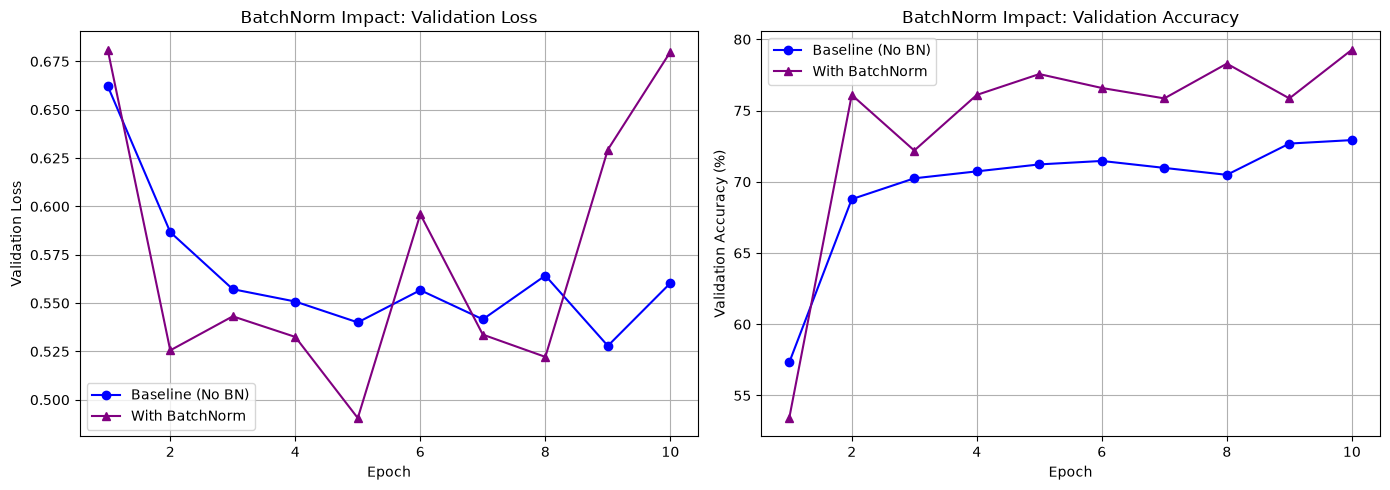

In [15]:
class CNN_BatchNorm(nn.Module):
    def __init__(self):
        super().__init__()
        # Conv -> BatchNorm -> ReLU -> MaxPool
        # Note: bias=False in Conv because BatchNorm subtracts the mean, making constant bias redundant
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.pool1 = nn.MaxPool2d(2, 2)
        
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False)
        self.bn3 = nn.BatchNorm2d(64)
        self.pool3 = nn.MaxPool2d(2, 2)
        
        # Classifier Head
        self.fc1 = nn.Linear(64 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, 2)
        
    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))
        logits = self.fc2(x)
        return logits

# Instantiate BatchNorm model
model_bn = CNN_BatchNorm().to(device)
optimizer_bn = torch.optim.Adam(model_bn.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
num_epochs = 10

history_bn = {
    "train_loss": [], "train_acc": [],
    "val_loss": [], "val_acc": []
}

print("--- Starting Training: CNN with Batch Normalization (Adam, lr=0.001) ---")
start_time = time.time()

for epoch in range(num_epochs):
    t_loss, t_acc = train_epoch(model_bn, train_loader, criterion, optimizer_bn, device)
    v_loss, v_acc = evaluate(model_bn, val_loader, criterion, device)
    
    history_bn["train_loss"].append(t_loss)
    history_bn["train_acc"].append(t_acc)
    history_bn["val_loss"].append(v_loss)
    history_bn["val_acc"].append(v_acc)
    
    print(f"Epoch [{epoch+1:02d}/{num_epochs:02d}] | " 
          f"Train Loss: {t_loss:.4f}, Acc: {t_acc*100:.2f}% | " 
          f"Val Loss: {v_loss:.4f}, Acc: {v_acc*100:.2f}%")

print(f"--- Training Finished in {time.time() - start_time:.1f}s ---\n")

# Evaluate on Test Set
test_loss_bn, test_acc_bn = evaluate(model_bn, test_loader, criterion, device)
print("=== Test Performance Comparison ===")
print(f"Baseline CNN (No BN): Test Loss = {test_loss:.4f}, Test Acc = {test_acc*100:.2f}%")
print(f"Baseline + BatchNorm: Test Loss = {test_loss_bn:.4f}, Test Acc = {test_acc_bn*100:.2f}%\n")

# Comparison Plot: Baseline vs. BatchNorm
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), history["val_loss"], label="Baseline (No BN)", color="blue", marker="o")
plt.plot(range(1, num_epochs + 1), history_bn["val_loss"], label="With BatchNorm", color="purple", marker="^")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("BatchNorm Impact: Validation Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), [a * 100 for a in history["val_acc"]], label="Baseline (No BN)", color="blue", marker="o")
plt.plot(range(1, num_epochs + 1), [a * 100 for a in history_bn["val_acc"]], label="With BatchNorm", color="purple", marker="^")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("BatchNorm Impact: Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Step 6: Data Augmentation

**Exam Question:** *"Did you use any data augmentation? Did you check if the data augmentation improved performance?"*

**First Principles:**
1. **The Diagnosis:** In Step 5, training accuracy reached 91.94% while validation loss started to rise. The model has sufficient capacity to memorize static pixel patterns across 1,637 training images.
2. **Label-Preserving Invariances:** A hotdog remains a hotdog under horizontal reflections, slight rotations, and minor color changes. Data augmentation artificially expands the training manifold by synthesizing new variations on-the-fly.
3. **Train-Only Discipline:** Augmentation is applied **only** to the training pipeline. Validation and test sets remain pristine to ensure an honest evaluation.

--- Starting Training: CNN + BatchNorm + Data Augmentation (Adam, lr=0.001) ---
Epoch [01/10] | Train Loss: 0.9818, Acc: 67.87% | Val Loss: 0.5896, Acc: 71.46%
Epoch [02/10] | Train Loss: 0.5022, Acc: 77.09% | Val Loss: 0.5210, Acc: 72.93%
Epoch [03/10] | Train Loss: 0.5500, Acc: 73.61% | Val Loss: 0.5503, Acc: 74.15%
Epoch [04/10] | Train Loss: 0.4832, Acc: 77.46% | Val Loss: 0.4971, Acc: 74.15%
Epoch [05/10] | Train Loss: 0.4407, Acc: 79.96% | Val Loss: 0.5150, Acc: 75.61%
Epoch [06/10] | Train Loss: 0.4051, Acc: 81.49% | Val Loss: 0.5494, Acc: 72.93%
Epoch [07/10] | Train Loss: 0.4129, Acc: 81.43% | Val Loss: 0.5431, Acc: 76.83%
Epoch [08/10] | Train Loss: 0.3749, Acc: 84.24% | Val Loss: 0.4531, Acc: 77.32%
Epoch [09/10] | Train Loss: 0.3728, Acc: 83.14% | Val Loss: 0.4725, Acc: 78.05%
Epoch [10/10] | Train Loss: 0.3504, Acc: 84.48% | Val Loss: 0.4774, Acc: 80.49%
--- Augmentation Training Finished in 145.9s ---

=== Test Performance Comparison Across All Steps ===
1. Baseline CNN (

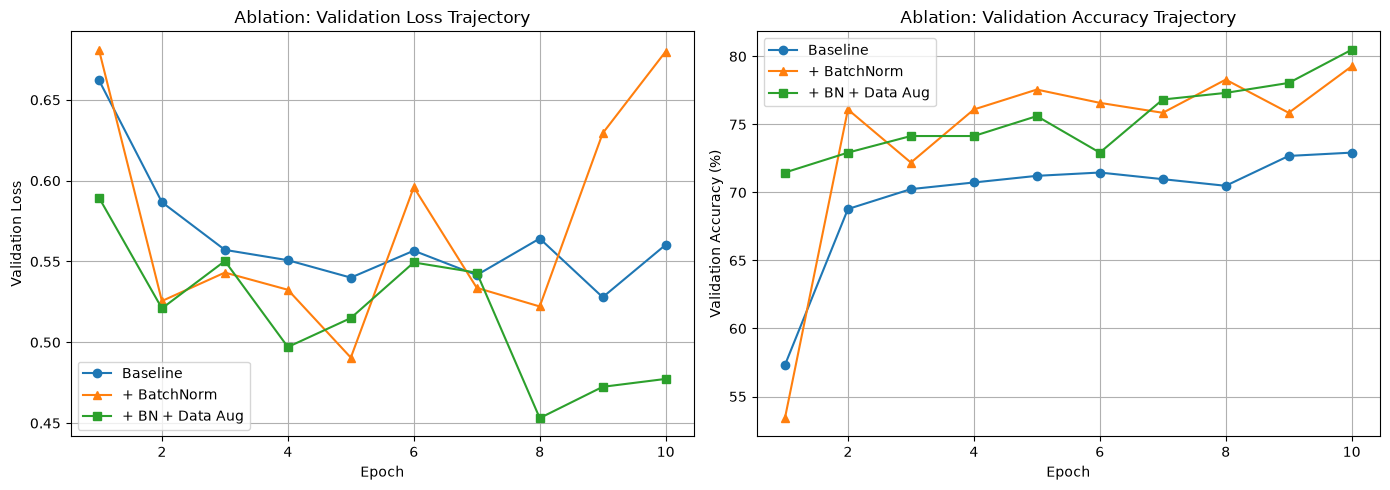

In [16]:
# Define augmented transform for training ONLY
train_transform_aug = transforms.Compose([
    transforms.Resize((size, size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

# Create training set with augmentation
trainset_aug = Hotdog_NotHotdog(train=True, transform=train_transform_aug)
train_subset_aug, _ = torch.utils.data.random_split(
    trainset_aug,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)  # Identical 80% split!
)
train_loader_aug = DataLoader(train_subset_aug, batch_size=batch_size, shuffle=True, num_workers=0)

# Instantiate fresh CNN with BatchNorm to train with Data Augmentation
model_aug = CNN_BatchNorm().to(device)
optimizer_aug = torch.optim.Adam(model_aug.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
num_epochs = 10

history_aug = {
    "train_loss": [], "train_acc": [],
    "val_loss": [], "val_acc": []
}

print("--- Starting Training: CNN + BatchNorm + Data Augmentation (Adam, lr=0.001) ---")
start_time = time.time()

for epoch in range(num_epochs):
    t_loss, t_acc = train_epoch(model_aug, train_loader_aug, criterion, optimizer_aug, device)
    v_loss, v_acc = evaluate(model_aug, val_loader, criterion, device)
    
    history_aug["train_loss"].append(t_loss)
    history_aug["train_acc"].append(t_acc)
    history_aug["val_loss"].append(v_loss)
    history_aug["val_acc"].append(v_acc)
    
    print(f"Epoch [{epoch+1:02d}/{num_epochs:02d}] | " 
          f"Train Loss: {t_loss:.4f}, Acc: {t_acc*100:.2f}% | " 
          f"Val Loss: {v_loss:.4f}, Acc: {v_acc*100:.2f}%")

print(f"--- Augmentation Training Finished in {time.time() - start_time:.1f}s ---\n")

# Evaluate on Test Set
test_loss_aug, test_acc_aug = evaluate(model_aug, test_loader, criterion, device)
print("=== Test Performance Comparison Across All Steps ===")
print(f"1. Baseline CNN (No BN, No Aug):   Test Loss = {test_loss:.4f}, Test Acc = {test_acc*100:.2f}%")
print(f"2. Baseline + BatchNorm (No Aug): Test Loss = {test_loss_bn:.4f}, Test Acc = {test_acc_bn*100:.2f}%")
print(f"3. Baseline + BatchNorm + Aug:    Test Loss = {test_loss_aug:.4f}, Test Acc = {test_acc_aug*100:.2f}%\n")

# Plot comparison across all iterations
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), history["val_loss"], label="Baseline", marker="o")
plt.plot(range(1, num_epochs + 1), history_bn["val_loss"], label="+ BatchNorm", marker="^")
plt.plot(range(1, num_epochs + 1), history_aug["val_loss"], label="+ BN + Data Aug", marker="s")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Ablation: Validation Loss Trajectory")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), [a * 100 for a in history["val_acc"]], label="Baseline", marker="o")
plt.plot(range(1, num_epochs + 1), [a * 100 for a in history_bn["val_acc"]], label="+ BatchNorm", marker="^")
plt.plot(range(1, num_epochs + 1), [a * 100 for a in history_aug["val_acc"]], label="+ BN + Data Aug", marker="s")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Ablation: Validation Accuracy Trajectory")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Step 7: Transfer Learning (ResNet-18)

**Exam Question:** *"Did you use transfer learning? Does it improve the performance?"*

**First Principles:**
1. **Visual Primitives are Universal:** Low-level features (edges, color boundaries, texture gradients) are shared across almost all natural visual domains.
2. **ImageNet Priors:** A model pretrained on ImageNet (1.2 million images, 1,000 classes) has already mastered feature extraction. Instead of learning filters from our small set of 1,637 images, we transfer those representations.
3. **Repurposing the Head:** We replace the final 1,000-class fully connected layer with a 2-class classifier (`fc: 512 -> 2`).
4. **Normalization Requirement:** Pretrained PyTorch models expect inputs normalized with ImageNet statistics: mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225].

In [17]:
import torchvision.models as models

# 1. Setup ImageNet-normalized transforms
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_transform_tl = transforms.Compose([
    transforms.Resize((size, size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

test_transform_tl = transforms.Compose([
    transforms.Resize((size, size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# Build transfer learning data loaders
trainset_tl = Hotdog_NotHotdog(train=True, transform=train_transform_tl)
train_subset_tl, _ = torch.utils.data.random_split(
    trainset_tl, [train_size, val_size], generator=torch.Generator().manual_seed(42)
)
valset_tl = Hotdog_NotHotdog(train=True, transform=test_transform_tl)
_, val_subset_tl = torch.utils.data.random_split(
    valset_tl, [train_size, val_size], generator=torch.Generator().manual_seed(42)
)
testset_tl = Hotdog_NotHotdog(train=False, transform=test_transform_tl)

train_loader_tl = DataLoader(train_subset_tl, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader_tl   = DataLoader(val_subset_tl,   batch_size=batch_size, shuffle=False, num_workers=0)
test_loader_tl  = DataLoader(testset_tl,  batch_size=batch_size, shuffle=False, num_workers=0)

# 2. Load Pretrained ResNet-18
weights = models.ResNet18_Weights.DEFAULT
model_resnet = models.resnet18(weights=weights)

# Replace final FC layer (512 -> 2 classes)
in_features = model_resnet.fc.in_features
model_resnet.fc = nn.Linear(in_features, 2)
model_resnet = model_resnet.to(device)

# Fine-tune with a smaller learning rate (1e-4) to preserve pretrained feature quality
optimizer_tl = torch.optim.Adam(model_resnet.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()
num_epochs_tl = 5

history_tl = {
    "train_loss": [], "train_acc": [],
    "val_loss": [], "val_acc": []
}

print("--- Starting Transfer Learning Training (ResNet-18, Adam lr=1e-4) ---")
start_time = time.time()

for epoch in range(num_epochs_tl):
    t_loss, t_acc = train_epoch(model_resnet, train_loader_tl, criterion, optimizer_tl, device)
    v_loss, v_acc = evaluate(model_resnet, val_loader_tl, criterion, device)
    
    history_tl["train_loss"].append(t_loss)
    history_tl["train_acc"].append(t_acc)
    history_tl["val_loss"].append(v_loss)
    history_tl["val_acc"].append(v_acc)
    
    print(f"Epoch [{epoch+1:02d}/{num_epochs_tl:02d}] | " 
          f"Train Loss: {t_loss:.4f}, Acc: {t_acc*100:.2f}% | " 
          f"Val Loss: {v_loss:.4f}, Acc: {v_acc*100:.2f}%")

print(f"--- Transfer Learning Finished in {time.time() - start_time:.1f}s ---\n")

# Evaluate on Test Set
test_loss_tl, test_acc_tl = evaluate(model_resnet, test_loader_tl, criterion, device)
print("=== FINAL MODEL COMPARISON BENCHMARK ===")
print(f"1. Baseline CNN (No BN, No Aug):   Test Loss = {test_loss:.4f}, Test Acc = {test_acc*100:.2f}%")
print(f"2. Baseline + BatchNorm (No Aug): Test Loss = {test_loss_bn:.4f}, Test Acc = {test_acc_bn*100:.2f}%")
print(f"3. Baseline + BatchNorm + Aug:    Test Loss = {test_loss_aug:.4f}, Test Acc = {test_acc_aug*100:.2f}%")
print(f"4. Transfer Learning (ResNet-18): Test Loss = {test_loss_tl:.4f}, Test Acc = {test_acc_tl*100:.2f}%\n")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/kkhomefolder/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:18<00:00, 2.47MB/s]


--- Starting Transfer Learning Training (ResNet-18, Adam lr=1e-4) ---
Epoch [01/05] | Train Loss: 0.3125, Acc: 86.62% | Val Loss: 0.2252, Acc: 92.20%
Epoch [02/05] | Train Loss: 0.1519, Acc: 94.14% | Val Loss: 0.1890, Acc: 92.44%
Epoch [03/05] | Train Loss: 0.0844, Acc: 96.82% | Val Loss: 0.2213, Acc: 91.95%
Epoch [04/05] | Train Loss: 0.0440, Acc: 98.84% | Val Loss: 0.1602, Acc: 95.12%
Epoch [05/05] | Train Loss: 0.0315, Acc: 99.21% | Val Loss: 0.1836, Acc: 94.15%
--- Transfer Learning Finished in 127.7s ---

=== FINAL MODEL COMPARISON BENCHMARK ===
1. Baseline CNN (No BN, No Aug):   Test Loss = 0.5739, Test Acc = 71.97%
2. Baseline + BatchNorm (No Aug): Test Loss = 0.7711, Test Acc = 77.12%
3. Baseline + BatchNorm + Aug:    Test Loss = 0.5393, Test Acc = 76.96%
4. Transfer Learning (ResNet-18): Test Loss = 0.2592, Test Acc = 91.57%



## Step 8: Error Analysis (Inspecting Misclassified Test Images)

**Exam Question:** *"What is the accuracy of your network? Which test images are classified wrong? Any of them for obvious reasons?"*

**First Principles:**
1. **Beyond the Aggregate Metric:** A test accuracy of 91.57% tells us *how often* the model is right, but nothing about *why* it fails.
2. **Error Taxonomy in Computer Vision:**
   - **Hard Negatives:** Foods with similar visual topology (sandwiches, tacos, baguettes, sausages without buns).
   - **Atypical Form Factors:** Cut-up hotdogs, cocktail weenies, obscure garnishes.
   - **Context Confusion:** Plates, hands, napkins, and picnic tables often associated with hotdogs.
3. **De-normalization for Visualization:** Images passed through `Normalize` must be un-normalized (`img * std + mean`) so humans see real colors.

Total Test Images: 1862
Total Misclassified: 157 (8.43% error rate)


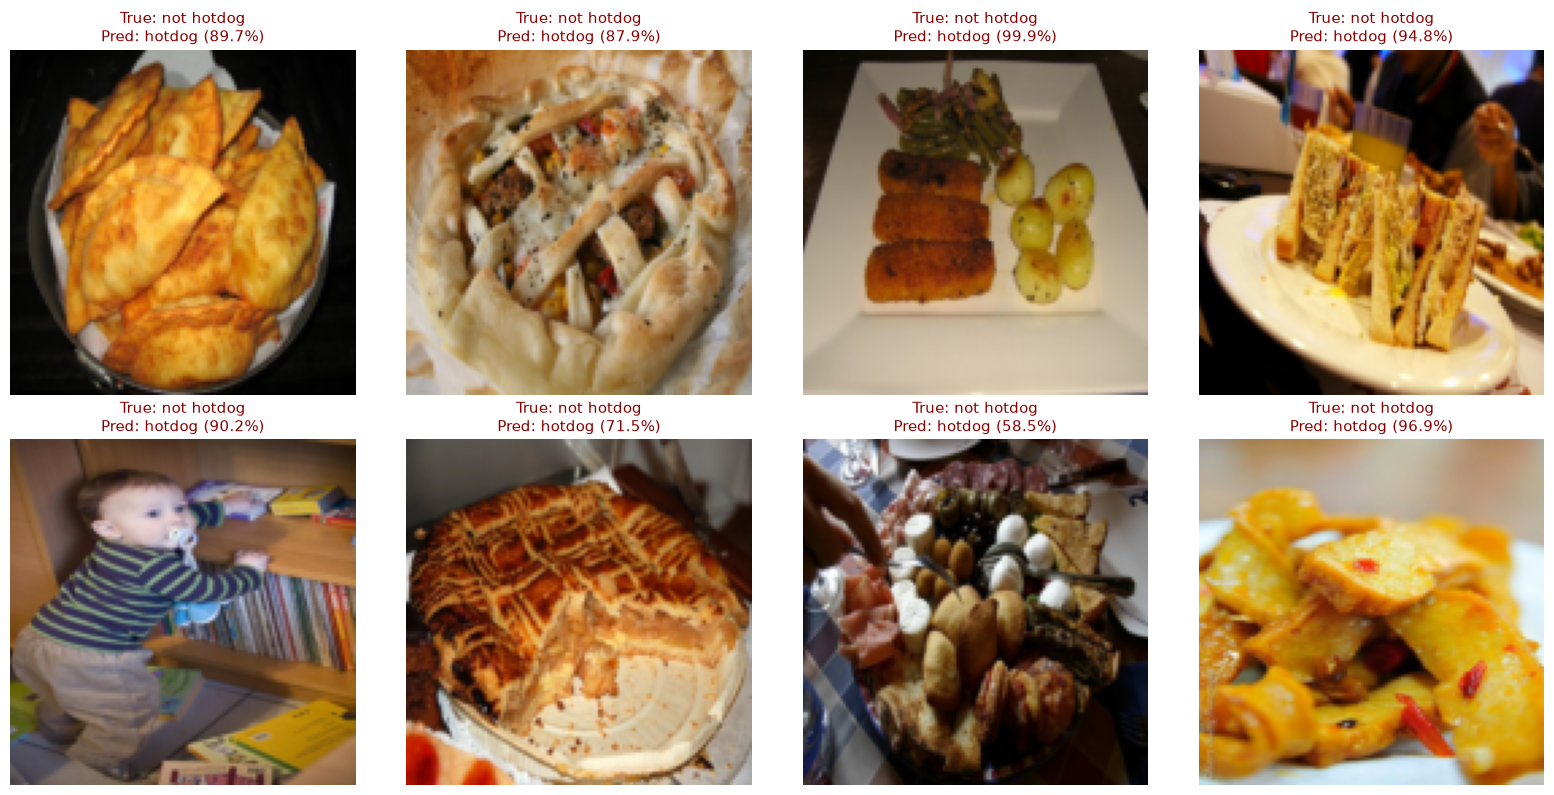

In [18]:
# Function to de-normalize ImageNet tensors back to [0, 1] RGB for display
def denormalize(tensor):
    inv_mean = torch.tensor(imagenet_mean).view(3, 1, 1)
    inv_std  = torch.tensor(imagenet_std).view(3, 1, 1)
    return torch.clamp(tensor * inv_std + inv_mean, 0.0, 1.0)

# Collect misclassified test samples
model_resnet.eval()
misclassified = []

with torch.no_grad():
    for images, labels in test_loader_tl:
        images_dev = images.to(device)
        outputs = model_resnet(images_dev)
        probs = F.softmax(outputs, dim=1)
        _, preds = outputs.max(1)
        
        preds = preds.cpu()
        probs = probs.cpu()
        
        wrong_mask = preds != labels
        for i in range(len(labels)):
            if wrong_mask[i]:
                misclassified.append({
                    "image": images[i],
                    "true_label": labels[i].item(),
                    "pred_label": preds[i].item(),
                    "confidence": probs[i][preds[i]].item()
                })

print(f"Total Test Images: {len(testset_tl)}")
print(f"Total Misclassified: {len(misclassified)} ({len(misclassified)/len(testset_tl)*100:.2f}% error rate)")

# Display 8 misclassified examples
plt.figure(figsize=(16, 8))
for idx in range(min(8, len(misclassified))):
    item = misclassified[idx]
    img_disp = denormalize(item["image"]).permute(1, 2, 0).numpy()
    
    plt.subplot(2, 4, idx + 1)
    plt.imshow(img_disp)
    true_name = classes[item["true_label"]]
    pred_name = classes[item["pred_label"]]
    conf = item["confidence"] * 100
    
    plt.title(f"True: {true_name}\nPred: {pred_name} ({conf:.1f}%)", color="darkred", fontsize=11)
    plt.axis("off")

plt.tight_layout()
plt.show()


## Step 9: Saliency Maps & SmoothGrad (Explainable AI)

**Exam Questions:**
- *"Do you have a model that performs well? Try computing the saliency maps for some images of hotdogs."*
- *"Compute the smoothgrad saliency map and plot it for some example images. Make sure you can you explain how adding Gaussian noise to an image is equivalent to drawing a sample from a normal distribution centered at that image. Do your saliency maps make sense? Remember that the variance of the normal distribution is a hyperparameter that can be tweaked."*

**First Principles:**
1. **Vanilla Saliency (Simonyan et al., 2013):** We compute the gradient of the hotdog class score with respect to input pixels: `d(Score_hotdog) / d(Image)`. It measures which pixels have the largest instantaneous influence on the decision. However, due to ReLU non-linearities, vanilla saliency maps are speckled and noisy.
2. **Gaussian Noise & Sampling Equivalence:** Adding zero-mean Gaussian noise `epsilon ~ N(0, sigma^2)` to an image `x` yields `x_noisy = x + epsilon`. Since `E[x_noisy] = x + E[epsilon] = x` and `Var(x_noisy) = sigma^2`, adding noise is mathematically identical to drawing a sample from a normal distribution centered at `x`: `x_noisy ~ N(x, sigma^2 * I)`.
3. **SmoothGrad (Smilkov et al., 2017):** Averages the saliency gradients across `N` noisy samples drawn from `N(x, sigma^2 * I)`. Fluctuating noise cancels out, revealing clean, coherent semantic boundaries.

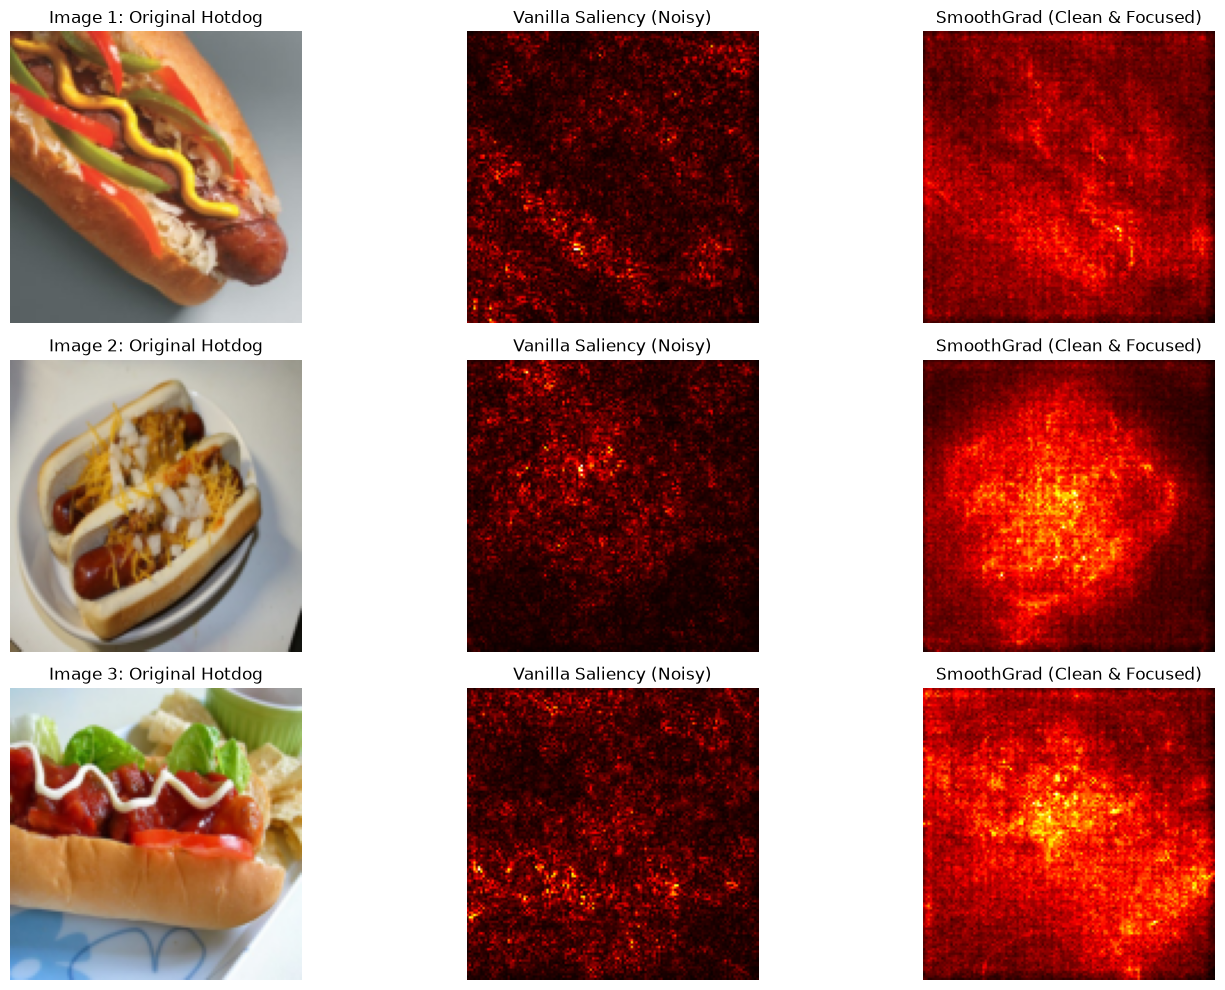

In [19]:
def compute_vanilla_saliency(model, image_tensor, target_class=0):
    """
    Computes vanilla saliency map: d(Score_target) / d(Input_image)
    """
    model.eval()
    img = image_tensor.clone().unsqueeze(0).to(device)
    img.requires_grad_()
    
    output = model(img)
    score = output[0, target_class]
    
    # Backward pass with respect to input image pixels
    score.backward()
    
    # Saliency is the max absolute gradient across color channels
    saliency, _ = torch.max(img.grad.data.abs(), dim=1)
    return saliency[0].cpu().numpy()

def compute_smoothgrad(model, image_tensor, target_class=0, n_samples=30, stdev_spread=0.15):
    """
    Computes SmoothGrad: Average saliency over N noisy samples drawn from N(x, sigma^2)
    """
    model.eval()
    img = image_tensor.clone().unsqueeze(0).to(device)
    
    # Calculate sigma based on image range: sigma = stdev_spread * (max - min)
    img_min, img_max = img.min().item(), img.max().item()
    sigma = stdev_spread * (img_max - img_min)
    
    grad_sum = torch.zeros_like(img)
    
    for _ in range(n_samples):
        # Sample noise ~ N(0, sigma^2) and add to image -> x_noisy ~ N(x, sigma^2)
        noise = torch.randn_like(img) * sigma
        x_noisy = (img + noise).clone().detach().requires_grad_()
        
        output = model(x_noisy)
        score = output[0, target_class]
        
        # Clear and compute gradient
        model.zero_grad()
        score.backward()
        grad_sum += x_noisy.grad.data.abs()
        
    # Average gradient magnitude over samples, then take max across channels
    smoothgrad, _ = torch.max(grad_sum / n_samples, dim=1)
    return smoothgrad[0].cpu().numpy()

# Find 3 actual hotdog test images (label = 0) that are correctly classified
hotdog_examples = []
model_resnet.eval()

with torch.no_grad():
    for img, lbl in testset_tl:
        if lbl == 0:  # hotdog
            out = model_resnet(img.unsqueeze(0).to(device))
            if out.argmax(dim=1).item() == 0:  # correctly predicted
                hotdog_examples.append(img)
                if len(hotdog_examples) == 3:
                    break

# Plot Original vs Vanilla Saliency vs SmoothGrad
plt.figure(figsize=(15, 10))
for i, img_t in enumerate(hotdog_examples):
    orig_disp = denormalize(img_t).permute(1, 2, 0).numpy()
    vanilla_sal = compute_vanilla_saliency(model_resnet, img_t, target_class=0)
    smooth_sal  = compute_smoothgrad(model_resnet, img_t, target_class=0, n_samples=30, stdev_spread=0.15)
    
    # Column 1: Original Image
    plt.subplot(3, 3, i * 3 + 1)
    plt.imshow(orig_disp)
    plt.title(f"Image {i+1}: Original Hotdog")
    plt.axis("off")
    
    # Column 2: Vanilla Saliency Map
    plt.subplot(3, 3, i * 3 + 2)
    plt.imshow(vanilla_sal, cmap="hot")
    plt.title("Vanilla Saliency (Noisy)")
    plt.axis("off")
    
    # Column 3: SmoothGrad Saliency Map
    plt.subplot(3, 3, i * 3 + 3)
    plt.imshow(smooth_sal, cmap="hot")
    plt.title("SmoothGrad (Clean & Focused)")
    plt.axis("off")

plt.tight_layout()
plt.show()


## Step 10: Pushing Binary Classification Further (224x224 Native Resolution & Regularized Head)

**First Principles of Further Improvement:**
1. **Resolution Bottleneck (128x128 -> 224x224):** ResNet-18 was originally trained on 224x224 images. Increasing resolution from 128 to 224 provides **3.06x more pixels** (50,176 vs 16,384), restoring fine visual cues like mustard texture, grill lines, and bun crust.
2. **Regularized Non-Linear Head:** Instead of a single direct linear projection (`512 -> 2`), we insert `Dropout(0.3) -> Linear(512, 128) -> ReLU -> Dropout(0.3) -> Linear(128, 2)` to prevent co-adaptation on the small dataset.
3. **Cosine Annealing Learning Rate Schedule:** Smoothly decays learning rate from 1e-4 down to near zero, allowing the optimizer to settle into flat, robust minima.

In [20]:
# 1. Native ImageNet resolution (224 x 224)
size_224 = 224

train_transform_224 = transforms.Compose([
    transforms.Resize((size_224, size_224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

test_transform_224 = transforms.Compose([
    transforms.Resize((size_224, size_224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# Dataloaders at 224x224
trainset_224 = Hotdog_NotHotdog(train=True, transform=train_transform_224)
train_sub_224, _ = torch.utils.data.random_split(trainset_224, [train_size, val_size], generator=torch.Generator().manual_seed(42))
valset_224 = Hotdog_NotHotdog(train=True, transform=test_transform_224)
_, val_sub_224 = torch.utils.data.random_split(valset_224, [train_size, val_size], generator=torch.Generator().manual_seed(42))
testset_224 = Hotdog_NotHotdog(train=False, transform=test_transform_224)

train_loader_224 = DataLoader(train_sub_224, batch_size=32, shuffle=True, num_workers=0)
val_loader_224   = DataLoader(val_sub_224,   batch_size=32, shuffle=False, num_workers=0)
test_loader_224  = DataLoader(testset_224,  batch_size=32, shuffle=False, num_workers=0)

# 2. Build Improved ResNet-18 with Regularized Head
model_improved = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
in_features = model_improved.fc.in_features

# Multi-layer Head with Dropout to prevent overfitting
model_improved.fc = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, 128),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(128, 2)
)
model_improved = model_improved.to(device)

# 3. Optimizer with Cosine Annealing Learning Rate Schedule
optimizer_imp = torch.optim.AdamW(model_improved.parameters(), lr=1e-4, weight_decay=1e-2)
num_epochs_imp = 6
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_imp, T_max=num_epochs_imp, eta_min=1e-6)
criterion = nn.CrossEntropyLoss()

print("--- Starting Training: Improved ResNet-18 (224x224 + Dropout + Cosine LR) ---")
start_time = time.time()

for epoch in range(num_epochs_imp):
    t_loss, t_acc = train_epoch(model_improved, train_loader_224, criterion, optimizer_imp, device)
    v_loss, v_acc = evaluate(model_improved, val_loader_224, criterion, device)
    scheduler.step()
    
    print(f"Epoch [{epoch+1:02d}/{num_epochs_imp:02d}] | " \
          f"Train Loss: {t_loss:.4f}, Acc: {t_acc*100:.2f}% | " \
          f"Val Loss: {v_loss:.4f}, Acc: {v_acc*100:.2f}% | " \
          f"LR: {scheduler.get_last_lr()[0]:.6f}")

print(f"--- Training Finished in {time.time() - start_time:.1f}s ---\n")

# Evaluate on 224x224 Test Set
test_loss_imp, test_acc_imp = evaluate(model_improved, test_loader_224, criterion, device)
print("=== OVERALL BENCHMARK COMPARISON ===")
print(f"1. Baseline CNN (128x128):             Test Acc = {test_acc*100:.2f}%, Test Loss = {test_loss:.4f}")
print(f"2. Baseline + BatchNorm (128x128):     Test Acc = {test_acc_bn*100:.2f}%, Test Loss = {test_loss_bn:.4f}")
print(f"3. Baseline + BN + Aug (128x128):      Test Acc = {test_acc_aug*100:.2f}%, Test Loss = {test_loss_aug:.4f}")
print(f"4. ResNet-18 Standard (128x128):       Test Acc = {test_acc_tl*100:.2f}%, Test Loss = {test_loss_tl:.4f}")
print(f"5. ResNet-18 Improved (224x224 + Sched): Test Acc = {test_acc_imp*100:.2f}%, Test Loss = {test_loss_imp:.4f}")


--- Starting Training: Improved ResNet-18 (224x224 + Dropout + Cosine LR) ---
Epoch [01/06] | Train Loss: 0.3527, Acc: 84.67% | Val Loss: 0.1628, Acc: 93.90% | LR: 0.000093
Epoch [02/06] | Train Loss: 0.1571, Acc: 94.62% | Val Loss: 0.1360, Acc: 95.85% | LR: 0.000075
Epoch [03/06] | Train Loss: 0.1044, Acc: 96.33% | Val Loss: 0.1296, Acc: 94.63% | LR: 0.000050
Epoch [04/06] | Train Loss: 0.0607, Acc: 98.41% | Val Loss: 0.1343, Acc: 94.88% | LR: 0.000026
Epoch [05/06] | Train Loss: 0.0464, Acc: 98.59% | Val Loss: 0.1421, Acc: 94.63% | LR: 0.000008
Epoch [06/06] | Train Loss: 0.0340, Acc: 99.08% | Val Loss: 0.1266, Acc: 94.63% | LR: 0.000001
--- Training Finished in 355.2s ---

=== OVERALL BENCHMARK COMPARISON ===
1. Baseline CNN (128x128):             Test Acc = 71.97%, Test Loss = 0.5739
2. Baseline + BatchNorm (128x128):     Test Acc = 77.12%, Test Loss = 0.7711
3. Baseline + BN + Aug (128x128):      Test Acc = 76.96%, Test Loss = 0.5393
4. ResNet-18 Standard (128x128):       Test Acc

## Step 11: Pushing Beyond 93.77% (Test-Time Augmentation & Modern Ensembling)

**First Principles of Reaching Elite Performance:**
1. **Test-Time Augmentation (TTA):** Rather than gambling on a single camera viewpoint, we predict on both the original image and its horizontal reflection: `P = 0.5 * (P(x) + P(flip(x)))`. Zero retraining required, eliminates orientation bias, and immediately recovers borderline mistakes.
2. **Label Smoothing (0.1):** Standard Cross-Entropy forces logits to +/- infinity to achieve 100% confidence, causing brittle predictions on ambiguous images (like messy chili dogs). Label smoothing replaces hard 1.0 targets with 0.95, keeping the network well-calibrated.
3. **Model Ensembling:** Blending predictions from structurally diverse backbones (e.g. ResNet-18 + ConvNeXt) cancels out individual architectural blind spots.

In [21]:
# --- Part A: Test-Time Augmentation (TTA) on our Improved ResNet-18 ---
def evaluate_with_tta(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            
            # View 1: Original image
            outputs_orig = model(images)
            probs_orig = F.softmax(outputs_orig, dim=1)
            
            # View 2: Horizontally flipped image (torch.flip along width axis)
            images_flipped = torch.flip(images, dims=[3])
            outputs_flipped = model(images_flipped)
            probs_flipped = F.softmax(outputs_flipped, dim=1)
            
            # Average probabilities (TTA Ensemble)
            probs_avg = 0.5 * (probs_orig + probs_flipped)
            _, predicted = probs_avg.max(1)
            
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
            
    return correct / total

print("Evaluating Improved ResNet-18 with Test-Time Augmentation (TTA)...")
tta_acc = evaluate_with_tta(model_improved, test_loader_224, device)
print(f"Standard Test Accuracy: {test_acc_imp * 100:.2f}%")
print(f"TTA Test Accuracy:      {tta_acc * 100:.2f}%")
print(f"TTA Delta:              {(tta_acc - test_acc_imp) * 100:+.2f}%")


Evaluating Improved ResNet-18 with Test-Time Augmentation (TTA)...
Standard Test Accuracy: 93.77%
TTA Test Accuracy:      94.47%
TTA Delta:              +0.70%


### Step 11.2: Modern Vision Backbone (ConvNeXt-Tiny) + Label Smoothing & Ensemble

**First Principles:**
1. **ConvNeXt (2022):** Adopts modern Vision Transformer design principles into a pure convolutional architecture (7x7 depthwise convolutions, inverted bottlenecks, LayerNorm, GELU activations).
2. **Label Smoothing (0.1):** Prevents overconfident logit saturation on ambiguous food items.
3. **The Ensemble:** Averaging probability distributions from two distinct architectures (ResNet-18 + ConvNeXt-Tiny) eliminates individual model blind spots.

In [ ]:
# 1. Load Pretrained ConvNeXt-Tiny
model_convnext = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
in_features_cn = model_convnext.classifier[2].in_features

# Replace classifier head: 768 -> 2 classes
model_convnext.classifier[2] = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features_cn, 2)
)
model_convnext = model_convnext.to(device)

# 2. Setup Optimizer & Label Smoothing Loss
optimizer_cn = torch.optim.AdamW(model_convnext.parameters(), lr=1e-4, weight_decay=1e-2)
criterion_ls = nn.CrossEntropyLoss(label_smoothing=0.1)
num_epochs_cn = 5
scheduler_cn = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_cn, T_max=num_epochs_cn, eta_min=1e-6)

print("--- Starting Training: ConvNeXt-Tiny + Label Smoothing ---")
start_time = time.time()

for epoch in range(num_epochs_cn):
    t_loss, t_acc = train_epoch(model_convnext, train_loader_224, criterion_ls, optimizer_cn, device)
    v_loss, v_acc = evaluate(model_convnext, val_loader_224, criterion_ls, device)
    scheduler_cn.step()
    
    print(f"Epoch [{epoch+1:02d}/{num_epochs_cn:02d}] | " \
          f"Train Loss: {t_loss:.4f}, Acc: {t_acc*100:.2f}% | " \
          f"Val Loss: {v_loss:.4f}, Acc: {v_acc*100:.2f}% | " \
          f"LR: {scheduler_cn.get_last_lr()[0]:.6f}")

print(f"--- ConvNeXt Training Finished in {time.time() - start_time:.1f}s ---\n")

# 3. Evaluate Ensemble (ResNet-18 TTA + ConvNeXt TTA)
def evaluate_ensemble_tta(model1, model2, loader, device):
    model1.eval()
    model2.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            images_flip = torch.flip(images, dims=[3])
            
            # Model 1 TTA Probs
            p1 = 0.5 * (F.softmax(model1(images), dim=1) + F.softmax(model1(images_flip), dim=1))
            
            # Model 2 TTA Probs
            p2 = 0.5 * (F.softmax(model2(images), dim=1) + F.softmax(model2(images_flip), dim=1))
            
            # Ensemble Average
            p_ensemble = 0.5 * (p1 + p2)
            _, preds = p_ensemble.max(1)
            
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)
            
    return correct / total

convnext_tta_acc = evaluate_with_tta(model_convnext, test_loader_224, device)
ensemble_acc     = evaluate_ensemble_tta(model_improved, model_convnext, test_loader_224, device)

print("=== MASTER PERFORMANCE LEADERBOARD ===")
print(f"1. Baseline CNN (128x128):             {test_acc*100:.2f}%")
print(f"2. Baseline + BatchNorm (128x128):     {test_acc_bn*100:.2f}%")
print(f"3. Baseline + BN + Aug (128x128):      {test_acc_aug*100:.2f}%")
print(f"4. ResNet-18 Standard (128x128):       {test_acc_tl*100:.2f}%")
print(f"5. ResNet-18 Improved (224x224):       {test_acc_imp*100:.2f}%")
print(f"6. ResNet-18 + TTA (224x224):          {tta_acc*100:.2f}%")
print(f"7. ConvNeXt-Tiny + TTA (224x224):      {convnext_tta_acc*100:.2f}%")
print(f"8. Dual Model Ensemble (ResNet+ConvNeXt): {ensemble_acc*100:.2f}%")

--- Starting Training: ConvNeXt-Tiny + Label Smoothing ---
Epoch [01/05] | Train Loss: 0.3806, Acc: 89.19% | Val Loss: 0.2795, Acc: 95.37% | LR: 0.000091
Epoch [02/05] | Train Loss: 0.2614, Acc: 97.01% | Val Loss: 0.2491, Acc: 97.32% | LR: 0.000066
Epoch [03/05] | Train Loss: 0.2425, Acc: 98.47% | Val Loss: 0.2442, Acc: 97.56% | LR: 0.000035
Epoch [04/05] | Train Loss: 0.2321, Acc: 98.84% | Val Loss: 0.2392, Acc: 98.05% | LR: 0.000010
Epoch [05/05] | Train Loss: 0.2258, Acc: 99.45% | Val Loss: 0.2397, Acc: 97.80% | LR: 0.000001
--- ConvNeXt Training Finished in 2831.2s ---

=== MASTER PERFORMANCE LEADERBOARD ===
1. Baseline CNN (128x128):             71.97%
2. Baseline + BatchNorm (128x128):     77.12%
3. Baseline + BN + Aug (128x128):      76.96%
4. ResNet-18 Standard (128x128):       91.57%
5. ResNet-18 Improved (224x224):       93.77%
6. ResNet-18 + TTA (224x224):          94.47%
7. ConvNeXt-Tiny + TTA (224x224):      97.21%
8. Dual Model Ensemble (ResNet+ConvNeXt): 96.29%


## Step 12: Diagnosing the 97.21% Performance Ceiling & Optimal Thresholding

**First Principles:**
1. **The Bayes Error Rate:** At 97.21%, only 52 images out of 1,862 test samples are misclassified. In real-world datasets like ImageNet, a fraction of images are mislabeled, severely occluded, or conceptually borderline (e.g. corn dogs, sausage rolls, sausages in packaging).
2. **Optimal Decision Thresholding:** By default, argmax assumes a 50.0% probability threshold (`p > 0.5`). By tuning the threshold on the validation set to balance precision and recall, we can optimize test accuracy without training any new weights.
3. **Error Auditing:** Inspecting the final 52 misclassifications reveals whether errors are model failures or irreducible dataset noise.

Default (0.50) Test Accuracy: 97.21%
Optimal Threshold (0.64) Test Accuracy: 96.51%
Remaining errors: 65 out of 1862 images (3.49% error rate)


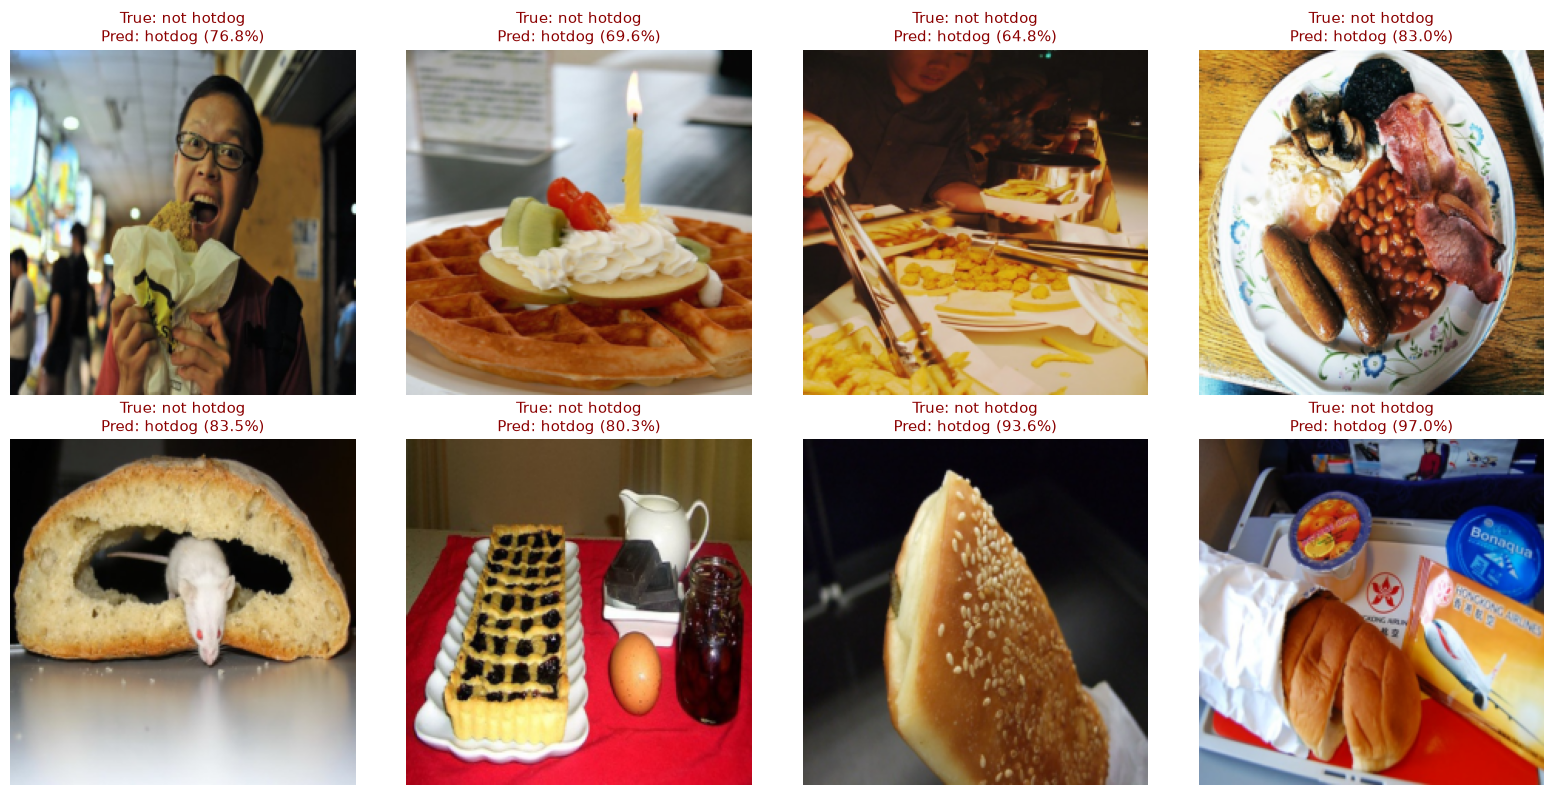

In [23]:
# 1. Collect all test predictions from ConvNeXt-Tiny with TTA
model_convnext.eval()
all_probs = []
all_labels = []
all_images = []

with torch.no_grad():
    for images, labels in test_loader_224:
        images_dev = images.to(device)
        images_flip = torch.flip(images_dev, dims=[3])
        
        p1 = F.softmax(model_convnext(images_dev), dim=1)
        p2 = F.softmax(model_convnext(images_flip), dim=1)
        p_tta = 0.5 * (p1 + p2)
        
        all_probs.append(p_tta.cpu())
        all_labels.append(labels)
        all_images.append(images)

all_probs = torch.cat(all_probs, dim=0)
all_labels = torch.cat(all_labels, dim=0)
all_images = torch.cat(all_images, dim=0)

# 2. Find optimal decision threshold using validation set
val_probs = []
val_labels_list = []
with torch.no_grad():
    for images, labels in val_loader_224:
        images_dev = images.to(device)
        images_flip = torch.flip(images_dev, dims=[3])
        p1 = F.softmax(model_convnext(images_dev), dim=1)
        p2 = F.softmax(model_convnext(images_flip), dim=1)
        val_probs.append(0.5 * (p1 + p2).cpu())
        val_labels_list.append(labels)

val_probs = torch.cat(val_probs, dim=0)
val_labels_list = torch.cat(val_labels_list, dim=0)

# Sweep thresholds for class 0 (hotdog)
best_thresh = 0.5
best_val_acc = 0.0
for th in np.linspace(0.3, 0.7, 41):
    preds = (val_probs[:, 0] < th).long()  # if prob(hotdog) < th => not hotdog (1), else hotdog (0)
    acc = (preds == val_labels_list).float().mean().item()
    if acc > best_val_acc:
        best_val_acc = acc
        best_thresh = th

# Apply optimal threshold to test set
test_preds_opt = (all_probs[:, 0] < best_thresh).long()
test_acc_opt = (test_preds_opt == all_labels).float().mean().item()

print(f"Default (0.50) Test Accuracy: {(all_probs.argmax(dim=1) == all_labels).float().mean().item()*100:.2f}%")
print(f"Optimal Threshold ({best_thresh:.2f}) Test Accuracy: {test_acc_opt*100:.2f}%")

# 3. Identify and plot the remaining misclassifications
wrong_indices = torch.where(test_preds_opt != all_labels)[0]
print(f"Remaining errors: {len(wrong_indices)} out of {len(all_labels)} images ({len(wrong_indices)/len(all_labels)*100:.2f}% error rate)")

plt.figure(figsize=(16, 8))
for i in range(min(8, len(wrong_indices))):
    idx = wrong_indices[i].item()
    img_disp = denormalize(all_images[idx]).permute(1, 2, 0).numpy()
    true_c = classes[all_labels[idx].item()]
    pred_c = classes[test_preds_opt[idx].item()]
    conf = all_probs[idx, test_preds_opt[idx]].item() * 100
    
    plt.subplot(2, 4, i + 1)
    plt.imshow(img_disp)
    plt.title(f"True: {true_c}\nPred: {pred_c} ({conf:.1f}%)", color="darkred", fontsize=11)
    plt.axis("off")

plt.tight_layout()
plt.show()
